In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(
    "../data/cleaned/datapulse_sales_cleaned.csv"
)

df["order_date"] = pd.to_datetime(df["order_date"])

df.head()

,order_id,order_date,customer_id,product,category,region,quantity,unit_price,discount,payment_method,returned,gross_sales,discount_amount,net_sales,year,month,month_name,day_name
0,O00001,2025-01-01 00:00:00.000000000,C0017,Headphones,Accessories,North,3,2500,0.00,Credit Card,No,7500,0.0,7500.0,2025,1,January,Wednesday
1,O00002,2025-01-01 02:36:59.483896779,C0056,Monitor,Electronics,East,4,15000,0.00,Credit Card,No,60000,0.0,60000.0,2025,1,January,Wednesday
2,O00003,2025-01-01 05:13:58.967793558,C0182,Laptop,Electronics,North,2,65000,0.05,Cash,No,130000,6500.0,123500.0,2025,1,January,Wednesday
3,O00004,2025-01-01 07:50:58.451690338,C0144,Laptop,Electronics,East,3,65000,0.10,Debit Card,No,195000,19500.0,175500.0,2025,1,January,Wednesday
4,O00005,2025-01-01 10:27:57.935587117,C0319,Laptop,Electronics,West,1,65000,0.00,Debit Card,No,65000,0.0,65000.0,2025,1,January,Wednesday


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_id         5000 non-null   object        
 1   order_date       5000 non-null   datetime64[ns]
 2   customer_id      5000 non-null   object        
 3   product          5000 non-null   object        
 4   category         5000 non-null   object        
 5   region           5000 non-null   object        
 6   quantity         5000 non-null   int64         
 7   unit_price       5000 non-null   int64         
 8   discount         5000 non-null   float64       
 9   payment_method   5000 non-null   object        
 10  returned         5000 non-null   object        
 11  gross_sales      5000 non-null   int64         
 12  discount_amount  5000 non-null   float64       
 13  net_sales        5000 non-null   float64       
 14  year             5000 non-null   int64  

In [6]:
# date as the index
df_time = df.set_index("order_date")

In [7]:
df_time.head()

,order_id,customer_id,product,category,region,quantity,unit_price,discount,payment_method,returned,gross_sales,discount_amount,net_sales,year,month,month_name,day_name
order_date,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00.000000000,O00001,C0017,Headphones,Accessories,North,3,2500,0.00,Credit Card,No,7500,0.0,7500.0,2025,1,January,Wednesday
2025-01-01 02:36:59.483896779,O00002,C0056,Monitor,Electronics,East,4,15000,0.00,Credit Card,No,60000,0.0,60000.0,2025,1,January,Wednesday
2025-01-01 05:13:58.967793558,O00003,C0182,Laptop,Electronics,North,2,65000,0.05,Cash,No,130000,6500.0,123500.0,2025,1,January,Wednesday
2025-01-01 07:50:58.451690338,O00004,C0144,Laptop,Electronics,East,3,65000,0.10,Debit Card,No,195000,19500.0,175500.0,2025,1,January,Wednesday
2025-01-01 10:27:57.935587117,O00005,C0319,Laptop,Electronics,West,1,65000,0.00,Debit Card,No,65000,0.0,65000.0,2025,1,January,Wednesday


In [8]:
# resample()
df_time["net_sales"].resample("ME").sum()

order_date
2025-01-31    15486360.0
2025-02-28    15545610.0
2025-03-31    15615460.0
2025-04-30    13693690.0
2025-05-31    17074470.0
2025-06-30    14767605.0
2025-07-31    15311520.0
2025-08-31    16063435.0
2025-09-30    15232320.0
2025-10-31    16218785.0
2025-11-30    15545440.0
2025-12-31    17603590.0
2026-01-31    13859840.0
2026-02-28    16289835.0
2026-03-31    15152405.0
2026-04-30    16053370.0
2026-05-31    15546240.0
2026-06-30    14034325.0
Freq: ME, Name: net_sales, dtype: float64

In [9]:
monthly_sales = (
    df_time["net_sales"]
    .resample("ME")
    .sum()
)

monthly_sales

order_date
2025-01-31    15486360.0
2025-02-28    15545610.0
2025-03-31    15615460.0
2025-04-30    13693690.0
2025-05-31    17074470.0
2025-06-30    14767605.0
2025-07-31    15311520.0
2025-08-31    16063435.0
2025-09-30    15232320.0
2025-10-31    16218785.0
2025-11-30    15545440.0
2025-12-31    17603590.0
2026-01-31    13859840.0
2026-02-28    16289835.0
2026-03-31    15152405.0
2026-04-30    16053370.0
2026-05-31    15546240.0
2026-06-30    14034325.0
Freq: ME, Name: net_sales, dtype: float64

In [10]:
# Monthly orders
monthly_orders = (
    df_time["order_id"]
    .resample("ME")
    .count()
)

monthly_orders

order_date
2025-01-31    285
2025-02-28    257
2025-03-31    284
2025-04-30    275
2025-05-31    285
2025-06-30    275
2025-07-31    284
2025-08-31    284
2025-09-30    276
2025-10-31    284
2025-11-30    275
2025-12-31    284
2026-01-31    285
2026-02-28    257
2026-03-31    284
2026-04-30    275
2026-05-31    284
2026-06-30    267
Freq: ME, Name: order_id, dtype: int64

In [11]:
# Monthly Average Order Value
monthly_aov = (
    monthly_sales / monthly_orders
)

monthly_aov

order_date
2025-01-31    54338.105263
2025-02-28    60488.754864
2025-03-31    54984.014085
2025-04-30    49795.236364
2025-05-31    59910.421053
2025-06-30    53700.381818
2025-07-31    53913.802817
2025-08-31    56561.390845
2025-09-30    55189.565217
2025-10-31    57108.397887
2025-11-30    56528.872727
2025-12-31    61984.471831
2026-01-31    48631.017544
2026-02-28    63384.571984
2026-03-31    53353.538732
2026-04-30    58375.890909
2026-05-31    54740.281690
2026-06-30    52563.014981
Freq: ME, dtype: float64

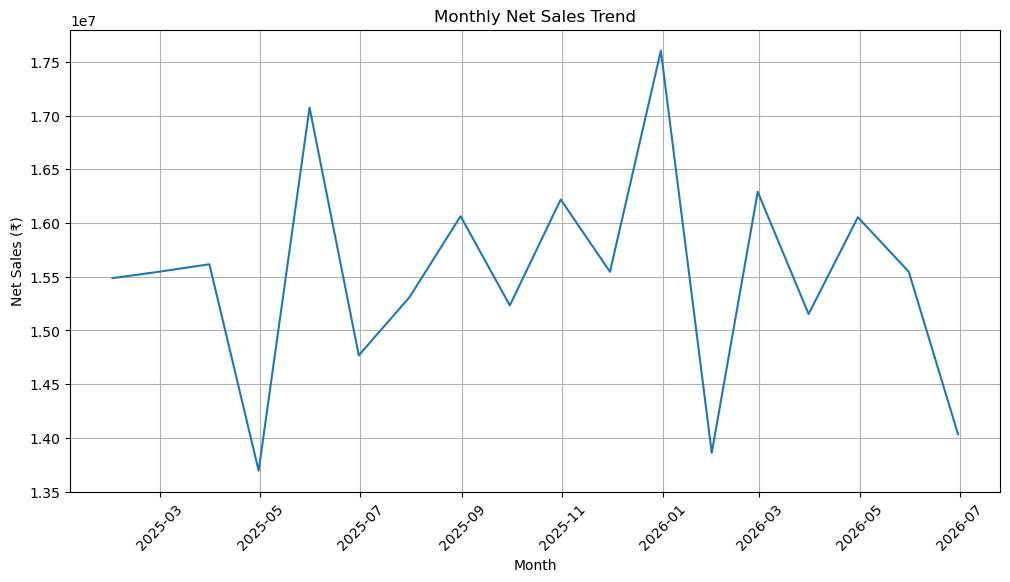

In [12]:
#first proper time-series chart
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values
)

plt.title("Monthly Net Sales Trend")
plt.xlabel("Month")
plt.ylabel("Net Sales (₹)")

plt.xticks(rotation=45)
plt.grid()

plt.show()

In [13]:
# Monthly growth rate
monthly_growth = monthly_sales.pct_change() * 100

monthly_growth

order_date
2025-01-31          NaN
2025-02-28     0.382595
2025-03-31     0.449323
2025-04-30   -12.306842
2025-05-31    24.688597
2025-06-30   -13.510610
2025-07-31     3.683163
2025-08-31     4.910780
2025-09-30    -5.173956
2025-10-31     6.476131
2025-11-30    -4.151637
2025-12-31    13.239574
2026-01-31   -21.266969
2026-02-28    17.532634
2026-03-31    -6.982453
2026-04-30     5.946020
2026-05-31    -3.159025
2026-06-30    -9.725278
Freq: ME, Name: net_sales, dtype: float64

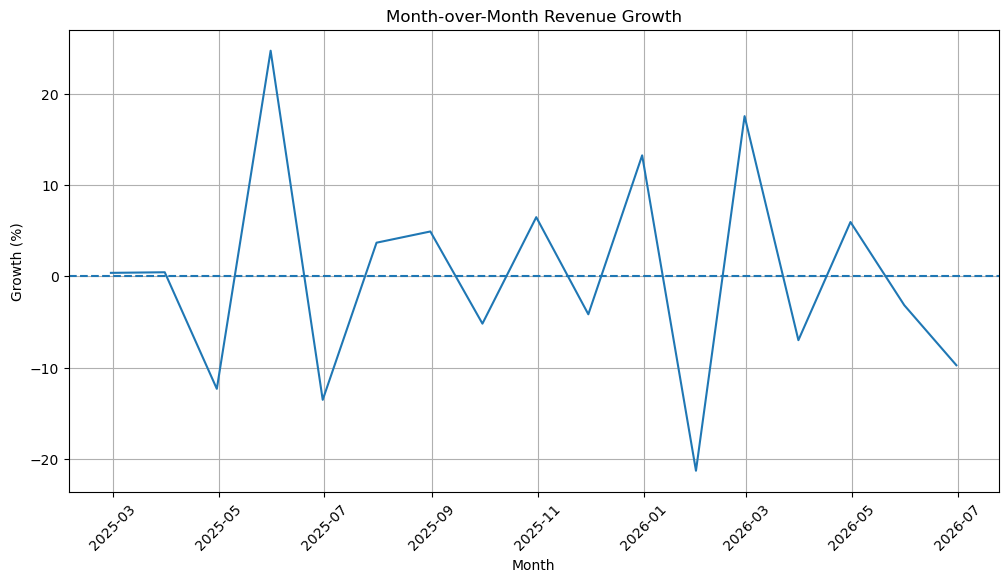

In [14]:
# Visualize growth
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_growth.index,
    monthly_growth.values
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Month-over-Month Revenue Growth")
plt.xlabel("Month")
plt.ylabel("Growth (%)")

plt.xticks(rotation=45)
plt.grid()

plt.show()

In [15]:
# Moving Average
monthly_sales_ma = (
    monthly_sales
    .rolling(window=3)
    .mean()
)

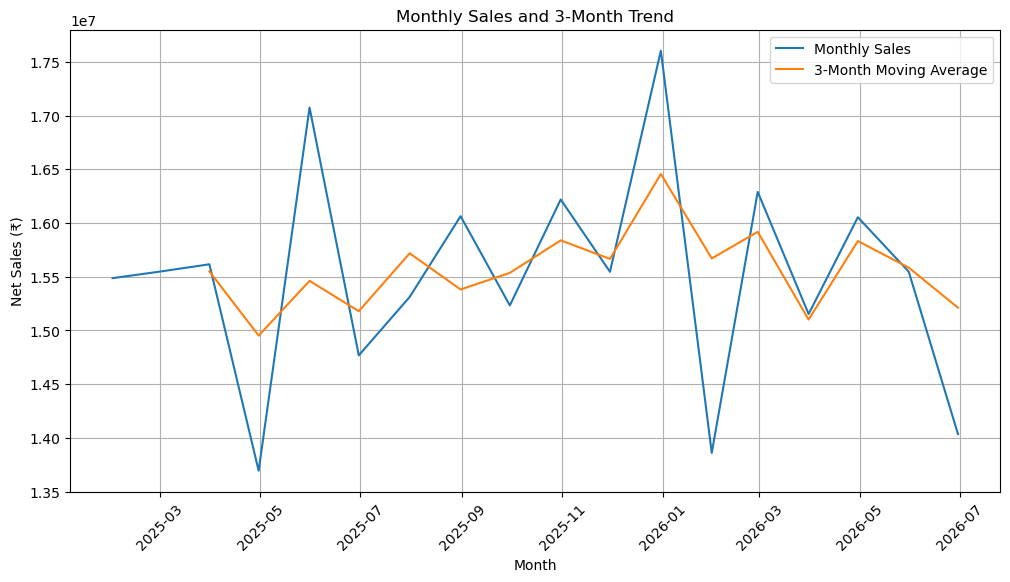

In [16]:
# actual revenue + trend
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    label="Monthly Sales"
)

plt.plot(
    monthly_sales_ma.index,
    monthly_sales_ma.values,
    label="3-Month Moving Average"
)

plt.title("Monthly Sales and 3-Month Trend")
plt.xlabel("Month")
plt.ylabel("Net Sales (₹)")

plt.xticks(rotation=45)
plt.legend()
plt.grid()

plt.show()


In [17]:
# the best month
best_month = monthly_sales.idxmax()
best_month_value = monthly_sales.max()

print("Best Month:", best_month)
print("Revenue: ₹", round(best_month_value, 2))

Best Month: 2025-12-31 00:00:00
Revenue: ₹ 17603590.0


In [18]:
# the worst month
worst_month = monthly_sales.idxmin()
worst_month_value = monthly_sales.min()

print("Worst Month:", worst_month)
print("Revenue: ₹", round(worst_month_value, 2))

Worst Month: 2025-04-30 00:00:00
Revenue: ₹ 13693690.0


In [19]:
# the strongest growth month
best_growth_month = monthly_growth.idxmax()
best_growth = monthly_growth.max()

print("Strongest Growth Month:", best_growth_month)
print("Growth:", round(best_growth, 2), "%")

Strongest Growth Month: 2025-05-31 00:00:00
Growth: 24.69 %


In [20]:
worst_growth_month = monthly_growth.idxmin()
worst_growth = monthly_growth.min()

print("Largest Monthly Decline:", worst_growth_month)
print("Growth:", round(worst_growth, 2), "%")

Largest Monthly Decline: 2026-01-31 00:00:00
Growth: -21.27 %


In [21]:
# a monthly summary table
monthly_summary = pd.DataFrame({
    "Revenue": monthly_sales,
    "Orders": monthly_orders,
    "AOV": monthly_aov,
    "MoM_Growth": monthly_growth
})

monthly_summary

,Revenue,Orders,AOV,MoM_Growth
order_date,,,,
2025-01-31,15486360.0,285,54338.105263,NaN
2025-02-28,15545610.0,257,60488.754864,0.382595
2025-03-31,15615460.0,284,54984.014085,0.449323
2025-04-30,13693690.0,275,49795.236364,-12.306842
2025-05-31,17074470.0,285,59910.421053,24.688597
2025-06-30,14767605.0,275,53700.381818,-13.510610
2025-07-31,15311520.0,284,53913.802817,3.683163
2025-08-31,16063435.0,284,56561.390845,4.910780
2025-09-30,15232320.0,276,55189.565217,-5.173956


In [22]:
monthly_summary["Revenue"] = monthly_summary["Revenue"].round(2)
monthly_summary["AOV"] = monthly_summary["AOV"].round(2)
monthly_summary["MoM_Growth"] = monthly_summary["MoM_Growth"].round(2)

In [23]:
monthly_summary.head()

,Revenue,Orders,AOV,MoM_Growth
order_date,,,,
2025-01-31,15486360.0,285,54338.11,NaN
2025-02-28,15545610.0,257,60488.75,0.38
2025-03-31,15615460.0,284,54984.01,0.45
2025-04-30,13693690.0,275,49795.24,-12.31
2025-05-31,17074470.0,285,59910.42,24.69


In [26]:
# Save the monthly analytical dataset
monthly_summary.to_csv(
    "../data/processed/monthly_sales_summary.csv"
)

OSError: Cannot save file into a non-existent directory: '..\data\processed'